# RiskAI – Explainable AI (XAI) mit SHAP

In dieser Phase analysieren wir die Entscheidungen unseres XGBoost-Modells.
Wir wollen verstehen:
1. Welche Features sind global am wichtigsten?
2. Wie beeinflussen die einzelnen Features (z. B. `HourOfDay` oder `Log_Amount`) die Vorhersage?
3. Lokale Erklärung einer einzelnen verdächtigen Transaktion.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# Daten laden
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Das trainierte XGBoost-Modell laden
model = joblib.load('../models/xgboost_smote.joblib')

print("Modell und Daten erfolgreich für SHAP-Analyse geladen!")


Modell und Daten erfolgreich für SHAP-Analyse geladen!


In [14]:

explainer = shap.TreeExplainer(model)

X_sample = pd.concat([
    X_test[y_test == 1],
    X_test[y_test == 0].sample(n=2000 - sum(y_test == 1), random_state=42)
])


shap_values = explainer(X_sample)

print(f"SHAP-Werte für {X_sample.shape[0]} Transaktionen erfolgreich berechnet!")


SHAP-Werte für 2000 Transaktionen erfolgreich berechnet!


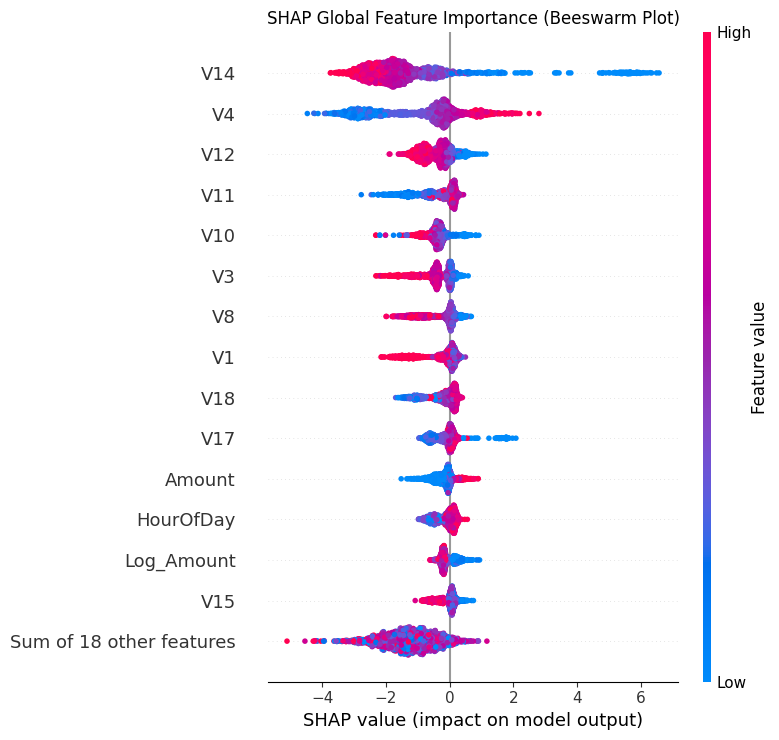

In [15]:
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Global Feature Importance (Beeswarm Plot)")
plt.tight_layout()
plt.show()


## Lokale Interpretierbarkeit: Waterfall-Plot

Wir wählen eine betrügerische Transaktion aus unserem Testset aus und erklären die Entscheidung des Modells im Detail.


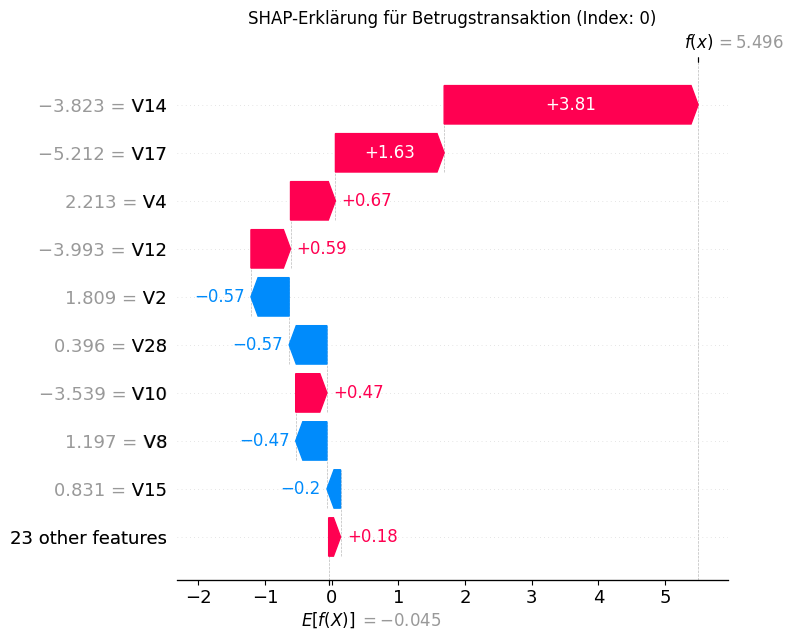

In [17]:

fraud_indices = np.where(y_test[X_sample.index] == 1)[0]
first_fraud_idx = fraud_indices[0]


plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[first_fraud_idx], max_display=10, show=False)
plt.title(f"SHAP-Erklärung für Betrugstransaktion (Index: {first_fraud_idx})")
plt.tight_layout()
plt.show()
